In [10]:
# Run this once if not installed
# !pip install kagglehub[pandas-datasets] scikit-learn matplotlib seaborn

import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [13]:
file_path = "Student_Marks.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "yasserh/student-marks-dataset",
    file_path
)

df.head()

/tmp/ipykernel_7663/149145490.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-marks-dataset' dataset.


,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [15]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


,number_courses,time_study,Marks
count,100.000000,100.000000,100.000000
mean,5.290000,4.077140,24.417690
std,1.799523,2.372914,14.326199
min,3.000000,0.096000,5.609000
25%,4.000000,2.058500,12.633000
50%,5.000000,4.022000,20.059500
75%,7.000000,6.179250,36.676250
max,8.000000,7.957000,55.299000


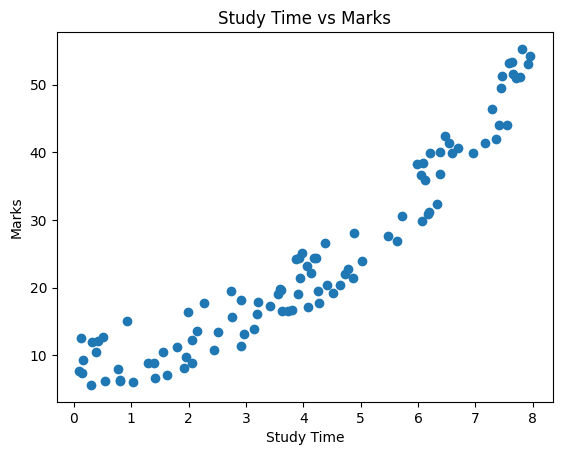

In [16]:
plt.scatter(df["time_study"], df["Marks"])
plt.xlabel("Study Time")
plt.ylabel("Marks")
plt.title("Study Time vs Marks")
plt.show()

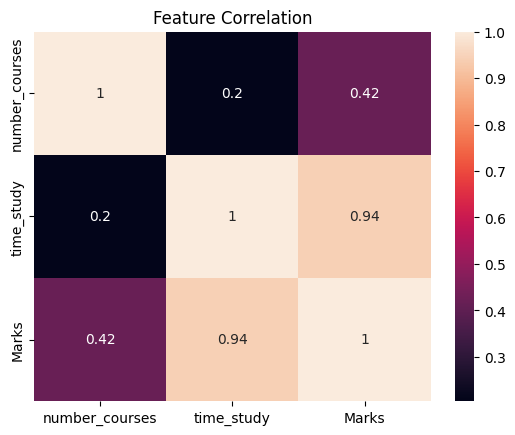

In [17]:
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

In [18]:
X = df[["number_courses", "time_study"]]
y = df["Marks"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [20]:
y_pred = model.predict(X_test)

print("Sample Predictions:", y_pred[:5])

Sample Predictions: [19.27278272 37.76035676 20.18779372  9.65670863 10.97508223]


In [21]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 3.0793452296666834
R2 Score: 0.9459936100591213


In [24]:
new_data = pd.DataFrame({
    "number_courses": [3],
    "time_study": [5]
})

prediction = model.predict(new_data)
print("Predicted Marks:", prediction[0])

Predicted Marks: 24.8509617429078


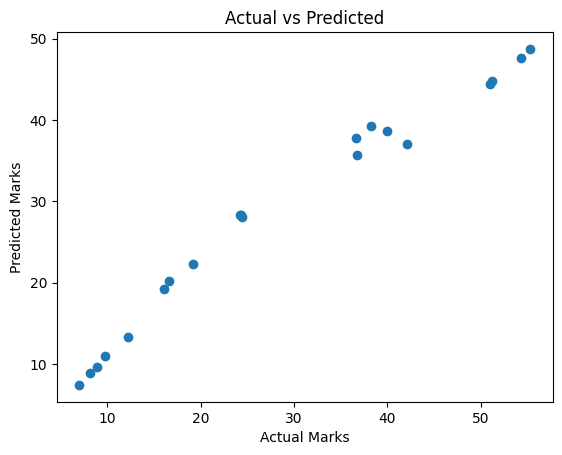

In [25]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")
plt.show()